# Day 1: Gaia Data Cleaning

**Theme:** Clean Gaia measurements so the regression model only sees reliable, physically meaningful data.

Today we will:

- load Gaia data
- inspect the required columns
- remove missing values
- remove invalid parallax values
- create `parallax_snr`
- keep stars with reliable parallax measurements
- save a cleaned dataset for Day 2

This matters because regression models learn patterns from whatever data we give them. If the data contains missing values, invalid parallaxes, or very noisy measurements, the model can learn misleading relationships.

## 1. Imports

We use `astroquery` to query Gaia DR3, `pandas` for table operations, `numpy` for numerical checks, and `matplotlib` for diagnostic plots.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.gaia import Gaia

plt.style.use("seaborn-v0_8")

In [6]:
import ssl
import astropy.utils.data as aud

aud.REMOTE_TIMEOUT = 60
# Disable SSL verification — workaround for corporate network inspection
ssl._create_default_https_context = ssl._create_unverified_context

In [10]:
df.columns.tolist()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_id        10000 non-null  int64  
 1   ra               10000 non-null  float64
 2   dec              10000 non-null  float64
 3   parallax         10000 non-null  float64
 4   parallax_error   10000 non-null  float32
 5   phot_g_mean_mag  9998 non-null   float32
 6   bp_rp            9907 non-null   float32
dtypes: float32(3), float64(3), int64(1)
memory usage: 429.8 KB


## 2. Load The Gaia Data

We will query Gaia DR3 directly using:

```python
from astroquery.gaia import Gaia
```

The first run may take a little time because it contacts the Gaia Archive. After that, the notebook saves a raw CSV cache at `data/raw/gaia_day1_raw.csv`, so reruns are faster and do not need another query unless you delete the cache or set `USE_CACHE = False`.

The query is intentionally small for learning. Increase `TOP_N` later if you want a larger sample.

In [7]:
TOP_N = 10_000
USE_CACHE = True

raw_cache_candidates = [
    Path("../data/raw/gaia_day1_raw.csv"),  # if the kernel starts in gaia-explorer/notebooks
    Path("data/raw/gaia_day1_raw.csv"),     # if the kernel starts in gaia-explorer
]

RAW_CACHE_PATH = next(
    (path for path in raw_cache_candidates if path.exists()),
    raw_cache_candidates[0] if raw_cache_candidates[0].parent.exists() else raw_cache_candidates[1],
)

if USE_CACHE and RAW_CACHE_PATH.exists():
    df = pd.read_csv(RAW_CACHE_PATH)
    print(f"Loaded cached Gaia data from: {RAW_CACHE_PATH}")
else:
    query = f"""
    SELECT TOP {TOP_N}
        source_id,
        ra,
        dec,
        parallax,
        parallax_error,
        phot_g_mean_mag,
        bp_rp
    FROM gaiadr3.gaia_source
    WHERE parallax IS NOT NULL
    """

    job = Gaia.launch_job_async(query)
    df = job.get_results().to_pandas()

    RAW_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(RAW_CACHE_PATH, index=False)
    print(f"Queried Gaia DR3 and cached raw data at: {RAW_CACHE_PATH}")

print("Original shape:", df.shape)
df.head()

INFO: Query finished. [astroquery.utils.tap.core]
Queried Gaia DR3 and cached raw data at: ../data/raw/gaia_day1_raw.csv
Original shape: (10000, 7)


,source_id,ra,dec,parallax,parallax_error,phot_g_mean_mag,bp_rp
0,137333159838693120,44.986883,35.274345,3.211433,0.959847,20.580927,2.616432
1,137338902210136064,45.039785,35.288983,0.952696,0.102076,17.505278,1.725426
2,137339245807513600,45.006828,35.323993,0.428972,0.570239,20.107737,2.047508
3,137339245807514624,45.008418,35.320334,0.247940,0.199228,18.486633,1.801111
4,137339486325672192,45.106500,35.341024,0.193908,0.055546,16.215153,1.152793


## 3. Inspect Required Columns

For Week 2, we need the columns below:

- `parallax`: apparent angular shift, used later for distance
- `parallax_error`: uncertainty in the parallax measurement
- `phot_g_mean_mag`: apparent brightness in Gaia's G band
- `bp_rp`: color index, useful as a temperature proxy
- `ra`, `dec`: sky coordinates

If any required column is missing, stop here and check your Gaia query or CSV file.

In [11]:
required_columns = [
    "parallax",
    "parallax_error",
    "phot_g_mean_mag",
    "bp_rp",
    "ra",
    "dec",
]

missing_required_columns = [col for col in required_columns if col not in df.columns]

if missing_required_columns:
    raise ValueError(f"Missing required columns: {missing_required_columns}")

df[required_columns].head()

,parallax,parallax_error,phot_g_mean_mag,bp_rp,ra,dec
0,3.211433,0.959847,20.580927,2.616432,44.986883,35.274345
1,0.952696,0.102076,17.505278,1.725426,45.039785,35.288983
2,0.428972,0.570239,20.107737,2.047508,45.006828,35.323993
3,0.247940,0.199228,18.486633,1.801111,45.008418,35.320334
4,0.193908,0.055546,16.215153,1.152793,45.106500,35.341024


## 4. Count Missing Values

Missing values matter because linear regression expects numeric inputs. A star with no `bp_rp`, for example, cannot be placed on the color-magnitude diagram.

In [12]:
missing_counts = df[required_columns].isna().sum().sort_values(ascending=False)
missing_counts.to_frame(name="missing_count")

,missing_count
bp_rp,93
phot_g_mean_mag,2
parallax,0
parallax_error,0
ra,0
dec,0


## 5. Remove Missing And Physically Invalid Values

We remove rows where required columns are missing. Then we keep only rows with:

- `parallax > 0`
- `parallax_error > 0`

A negative parallax can happen because of measurement noise, but it cannot be used with the simple distance formula `distance_pc = 1000 / parallax`. A zero or negative parallax error would also make the signal-to-noise calculation invalid.

In [13]:
rows_original = len(df)

clean_df = df.dropna(subset=required_columns).copy()
rows_after_missing = len(clean_df)

clean_df = clean_df[
    (clean_df["parallax"] > 0) &
    (clean_df["parallax_error"] > 0)
].copy()
rows_after_positive_parallax = len(clean_df)

summary = pd.DataFrame(
    {
        "step": [
            "original",
            "after required-column missing-value filter",
            "after positive parallax and parallax_error filter",
        ],
        "rows": [
            rows_original,
            rows_after_missing,
            rows_after_positive_parallax,
        ],
    }
)

summary["rows_removed_from_previous_step"] = summary["rows"].shift(1).fillna(summary["rows"]) - summary["rows"]
summary

,step,rows,rows_removed_from_previous_step
0,original,10000,0.0
1,after required-column missing-value filter,9907,93.0
2,after positive parallax and parallax_error filter,8253,1654.0


## 6. Create Parallax Signal-To-Noise

`parallax_snr` measures how strong the parallax measurement is compared with its uncertainty:

$$
\\text{parallax\_snr} = \\frac{\\text{parallax}}{\\text{parallax\_error}}
$$

Higher values mean the parallax measurement is more reliable.

In [14]:
clean_df["parallax_snr"] = clean_df["parallax"] / clean_df["parallax_error"]

clean_df[["parallax", "parallax_error", "parallax_snr"]].head()

,parallax,parallax_error,parallax_snr
0,3.211433,0.959847,3.345775
1,0.952696,0.102076,9.333179
2,0.428972,0.570239,0.752267
3,0.247940,0.199228,1.244503
4,0.193908,0.055546,3.490918


## 7. Keep Reliable Parallaxes

For this week, we keep stars with `parallax_snr > 5`. This is a conservative quality cut for a beginner project because Day 2 will compute distance and absolute magnitude from parallax.

In [15]:
snr_threshold = 5

rows_before_snr_filter = len(clean_df)
clean_df = clean_df[clean_df["parallax_snr"] > snr_threshold].copy()
rows_after_snr_filter = len(clean_df)

print("Original shape:", df.shape)
print("Cleaned shape:", clean_df.shape)
print("Rows removed total:", rows_original - rows_after_snr_filter)
print("Rows removed by SNR filter:", rows_before_snr_filter - rows_after_snr_filter)
print("Percent kept:", round(rows_after_snr_filter / rows_original * 100, 2), "%")

Original shape: (10000, 7)
Cleaned shape: (2413, 8)
Rows removed total: 7587
Rows removed by SNR filter: 5840
Percent kept: 24.13 %


## 8. Plot Diagnostic Histograms

These plots help us check whether the cleaned values look reasonable before using them in a model.

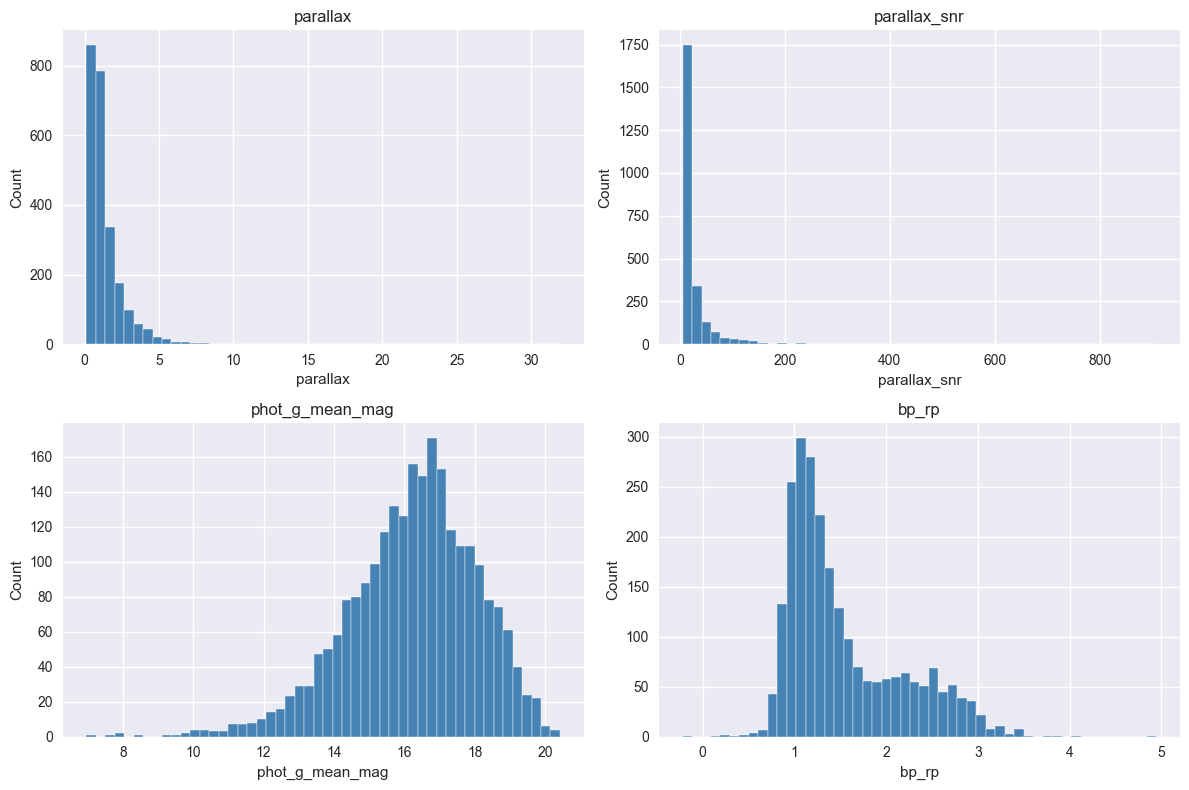

In [16]:
columns_to_plot = ["parallax", "parallax_snr", "phot_g_mean_mag", "bp_rp"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, columns_to_plot):
    ax.hist(clean_df[col], bins=50, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## 9. Save The Cleaned Dataset

We save the cleaned table so Day 2 can focus on creating the regression target instead of repeating all cleaning steps.

In [17]:
output_candidates = [
    Path("../data/processed/gaia_clean_day1.csv"),  # if the kernel starts in gaia-explorer/notebooks
    Path("data/processed/gaia_clean_day1.csv"),     # if the kernel starts in gaia-explorer
]

OUTPUT_PATH = output_candidates[0] if output_candidates[0].parent.exists() else output_candidates[1]
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

clean_df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved cleaned data to: {OUTPUT_PATH}")
print("Saved shape:", clean_df.shape)

Saved cleaned data to: ../data/processed/gaia_clean_day1.csv
Saved shape: (2413, 8)


## Reflection Questions

1. How much data was removed during cleaning?

2. Why is negative or near-zero parallax problematic?

3. What trade-off happens when we require `parallax_snr > 5`?

4. Looking at the histograms, do any columns still have suspicious values?

5. If the SNR threshold were changed from `5` to `10`, what do you expect would happen to the dataset size and quality?